# Tutorial notebook for the usage of LSST related functions

## Make sure to have `rubin_sim` installed !

### 1: `get_lsst_observations`
Query a SQL database to get planned observations (works for `baseline_v5.1.1_10yrs.db`). Assumes a table named `observations` to extract:
- `observationStartMJD`
- `filter`
- `fiveSigmaDepth`
- `fieldRA`
- `fieldDec`

In [1]:
from peket.kn_side.utils import get_lsst_observations 

df = get_lsst_observations(db_path='/home/liteul/memoir_code/baseline_v5.1.1_10yrs.db', full_df=True)
df.head(10)

/home/liteul/anaconda3/envs/peket/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/liteul/peket/src/peket/kn_side/utils.py:18: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import MRSUN_SI


Install m4opt if you want to use uvex filters
afterglowpy not available. Need fiesta or afterglowpy for GRB analyses. 
Install wrapt_timeout_decorator if you want to timeout simulations.


I0000 00:00:1784036554.666044  451841 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784036555.834816  451841 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784036560.239857  451841 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Install gaussian-process-api if you want to use it...


,expMJD,_ra,_dec,filter,fiveSigmaDepth
0,60981.002252,263.940171,-25.278365,r,22.430188
1,60981.002498,262.851107,-22.591159,r,22.301241
2,60981.002744,261.834513,-19.886311,r,22.143394
3,60981.002988,264.065758,-17.653606,r,22.254286
4,60981.003234,263.101622,-14.904447,r,22.116414
5,60981.003481,262.197819,-12.138795,r,22.088670
6,60981.003731,260.885516,-17.164857,r,22.131134
7,60981.003975,258.584949,-19.369987,r,22.048133
8,60981.004221,259.514781,-22.073909,r,22.124146
9,60981.004473,256.202626,-21.528916,r,22.012620


### 2: `get_source_observations`
Find the observations relevant for a source that started at `t0_mjd` located at `ra` `dec` over a specified period of time

In [2]:
from peket.kn_side.utils import get_source_observations

df_source = get_source_observations(df_lsst=df,
                                    t0_mjd=60000.0,
                                    ra=150.0,
                                    dec=2.0,
                                    duration=20) # in days

No observations during the KN lifetime.


For example here, no source was found for these params, let's try some others

In [3]:
df_source = get_source_observations(df_lsst=df,
                                    t0_mjd=61901.85245464677,
                                    ra=284.1873323151213,
                                    dec=11.042815638703047,
                                    duration=20) # in days

print(df_source)

              expMJD         _ra       _dec filter  fiveSigmaDepth  time_days  \
546407  61911.261862  285.100810  10.242647      g       24.577281   9.409408   
546409  61911.262709  282.698429  11.813190      g       24.575022   9.410255   
546459  61911.286191  285.100810  10.242647      r       24.372267   9.433736   
546461  61911.287037  282.698429  11.813190      r       24.358212   9.434582   
553246  61919.292816  283.882409  11.556039      i       23.641945  17.440362   
553298  61919.316443  283.882409  11.556039      z       22.949555  17.463988   

        in_fov  
546407    True  
546409    True  
546459    True  
546461    True  
553246    True  
553298    True  


It returns a pandas dataframe containing the epoch of the observation (MJD), the ra and dec, the filter, the 5$\sigma$ depth and the time since t0 (time since merger as those function were made with KNe and afterglow in mind).

### 3: `find_valid_sources`
As finding sources "randomly" is quite hard, this functions finds valid sources in the observation dataframe that have observations during the expected transient lifetime and are located within the field of view.

In [4]:
from peket.kn_side.utils import find_valid_sources

valid_sources = find_valid_sources(df_lsst=df,
                                   n_sources=5,
                                   duration=10, # in days
                                   min_observations=5,
                                   seed=95)
# returns a list of dictionaries with the valid sources and their parameters (ra, dec, t0_mjd) and the observartions (same as df_source)
print(valid_sources[0])
print("Number of observations for the last valid source: ", len(valid_sources[-1]['observations'])) # number of observations for the last valid source

{'ra': 349.11008354915106, 'dec': -43.90407525018234, 't0_mjd': 62449.436596027714, 'observations':               expMJD         _ra       _dec filter  fiveSigmaDepth  time_days  \
821266  62451.086576  347.270726 -44.521506      u       23.183488   1.649980   
821287  62451.097490  351.193873 -44.349128      u       23.196932   1.660894   
821323  62451.117721  347.270726 -44.521506      r       23.893354   1.681125   
821344  62451.128607  351.193873 -44.349128      r       23.970550   1.692011   
823107  62455.081667  349.015261 -42.412330      i       23.347951   5.645071   

        in_fov  
821266    True  
821287    True  
821323    True  
821344    True  
823107    True  }
Number of observations for the last valid source:  12


### 4: `get_obs_mag_from_lsst`
Computes the observed mag based the 5 sigma depth mag using ``rubin_sim.phot_utils``

In [5]:
# Calculate signal to noise in flux and the magnitude error using the model from equation (5) of arXiv:0805.2366
from peket.kn_side.utils import get_obs_mag_from_lsst
mag1, err1 = get_obs_mag_from_lsst(filter='g',      # supported are ugrizy
                                   model_mag=18,    # "true" magnitude of the source
                                   m5=23.5,         # 5-sigma depth for the filter
                                   kind='svd')      
# if kind='svd', then the function uses the throughput of the sdssu filter instead of lsstu and the pan-starrs grizy instead of lsst grizy, this is because the SVD models in NMMA do not have the lsst filters so I use those throughput instead
# if kind is anything else, it will uses the lsst filters throughput 
mag2, err2 = get_obs_mag_from_lsst(filter='g',      # supported are ugrizy
                                   model_mag=18,    # "true" magnitude of the source
                                   m5=23.5,         # 5-sigma depth for the filter
                                   kind='lsst')
print("Magnitude and error using SVD filters: ", mag1, err1)
print("Magnitude and error using LSST filters: ", mag2, err2)

Magnitude and error using SVD filters:  18.00291915508622 0.005453762654216489
Magnitude and error using LSST filters:  18.002785223036145 0.005423124336173801


## 5: `generate_synth_lc_lsst`
Uses `nmma` and `fiesta` with the previous functions to generate a synthetic light curve based on the LSST observations of a given source and a given model. The light curve is generated for each filter in the observations and then merged together to have a full light curve with all the filters.

In [6]:
from peket.kn_side.utils import generate_synth_lc_lsst

parameters = {
   'log10_mej_dyn': -2.5,
   'v_ej_dyn': 0.235,
   'Ye_dyn': 0.25,
   'log10_mej_wind': -1,
   'v_ej_wind': 0.1,
   'Ye_wind': 0.3,
   'inclination_EM': 0.7853981633974483,
   'luminosity_distance': 70.0,
   }
lc_df = generate_synth_lc_lsst(source=valid_sources[0], # output of find_valid_sources or get_source_observations
                               model_name='Bu2026_MLP', # All fiesta surrogates are available (if you have already downloaded them) as well as Bu2019lm and Ka2017
                               params = parameters,     # Model parameters 
                               save=False,              # Save the light curve to a (preferably) .dat file
                               filename='synth_lc.dat', # Name of the file to save the light curve (if save=True)
                               svd_path="/home/liteul/memoir_code/NMMA/svdmodels") # Path to the svd models
print("\n\nSynthetic light curve df has columns: 0,1,2,3 corresponding to epoch (ISOT), filter, magnitude and magnitude error (inf = UL)")
print(lc_df)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Generating synthetic light curve for model: Bu2026_MLP
Filters in the observations: ['u', 'r', 'i']


15:42 fiesta INFO    : Loading surrogate Bu2026_MLP. This surrogate should only be used in the following parameter ranges:
15:42 fiesta INFO    : 	 log10_mej_dyn: (-4.0, -1.3010299956639813)
15:42 fiesta INFO    : 	 v_ej_dyn: (0.12, 0.35)
15:42 fiesta INFO    : 	 Ye_dyn: (0.15, 0.35)
15:42 fiesta INFO    : 	 log10_mej_wind: (-4.0, -0.5502131530142267)
15:42 fiesta INFO    : 	 v_ej_wind: (0.05, 0.15)
15:42 fiesta INFO    : 	 Ye_wind: (0.2, 0.4)
15:42 fiesta INFO    : 	 inclination_EM: (0.0, 1.5707963267948966)
15:42 fiesta INFO    : Surrogate Bu2026_MLP is loading with source-frame time range [ 0.19405578 27.52765949] days.


15:42 fiesta INFO    : Surrogate Bu2026_MLP is loading with the following filters: ['lsstu', 'lsstr', 'lssti'].
15:42 fiesta INFO    : Loaded for surrogate Bu2026_MLP from /home/liteul/fiestaEM/src/fiesta/surrogates/KN/Bu2026_MLP/model.


Sample times for filter u:
[1.64997984 1.66089363]
Trigger ISO: 2029-11-09T10:28:41.897
Light Curve generated
ISO times sample: ['2029-11-11T02:04:40.155', '2029-11-11T02:20:23.106']
Sample times for filter r:
[1.68112539 1.69201128]
Trigger ISO: 2029-11-09T10:28:41.897
Light Curve generated
ISO times sample: ['2029-11-11T02:49:31.131', '2029-11-11T03:05:11.671']
Sample times for filter i:
[5.64507086]
Trigger ISO: 2029-11-09T10:28:41.897
Light Curve generated
ISO times sample: ['2029-11-15T01:57:36.018']


Synthetic light curve df has columns: 0,1,2,3 corresponding to epoch (ISOT), filter, magnitude and magnitude error (inf = UL)
                         0      1          2         3
0  2029-11-11T02:04:40.155  lsstu  22.335926  0.097129
1  2029-11-11T02:20:23.106  lsstu  22.275281  0.100175
2  2029-11-11T02:49:31.131  lsstr  18.549145  0.005679
3  2029-11-11T03:05:11.671  lsstr  18.577910  0.005668
4  2029-11-15T01:57:36.018  lssti  21.772567  0.049159


plot of the lc:

15:42 fiesta INFO    : Loading surrogate Bu2026_MLP. This surrogate should only be used in the following parameter ranges:
15:42 fiesta INFO    : 	 log10_mej_dyn: (-4.0, -1.3010299956639813)
15:42 fiesta INFO    : 	 v_ej_dyn: (0.12, 0.35)
15:42 fiesta INFO    : 	 Ye_dyn: (0.15, 0.35)
15:42 fiesta INFO    : 	 log10_mej_wind: (-4.0, -0.5502131530142267)
15:42 fiesta INFO    : 	 v_ej_wind: (0.05, 0.15)
15:42 fiesta INFO    : 	 Ye_wind: (0.2, 0.4)
15:42 fiesta INFO    : 	 inclination_EM: (0.0, 1.5707963267948966)
15:42 fiesta INFO    : Surrogate Bu2026_MLP is loading with source-frame time range [ 0.19405578 27.52765949] days.
15:42 fiesta INFO    : Surrogate Bu2026_MLP is loading with the following filters: ['lssti', 'lsstu', 'lsstr'].
15:42 fiesta INFO    : Loaded for surrogate Bu2026_MLP from /home/liteul/fiestaEM/src/fiesta/surrogates/KN/Bu2026_MLP/model.


Generating synthetic light curve for model: Bu2026_MLP
Trigger ISO: 2029-11-09T10:28:41.897
Light Curve generated
ISO times sample: ['2029-11-09T10:28:41.897', '2029-11-09T12:52:41.897', '2029-11-09T15:16:41.897', '2029-11-09T17:40:41.897', '2029-11-09T20:04:41.897', '2029-11-09T22:28:41.897', '2029-11-10T00:52:41.897', '2029-11-10T03:16:41.897', '2029-11-10T05:40:41.897', '2029-11-10T08:04:41.897', '2029-11-10T10:28:41.897', '2029-11-10T12:52:41.897', '2029-11-10T15:16:41.897', '2029-11-10T17:40:41.897', '2029-11-10T20:04:41.897', '2029-11-10T22:28:41.897', '2029-11-11T00:52:41.897', '2029-11-11T03:16:41.897', '2029-11-11T05:40:41.897', '2029-11-11T08:04:41.897', '2029-11-11T10:28:41.897', '2029-11-11T12:52:41.897', '2029-11-11T15:16:41.897', '2029-11-11T17:40:41.897', '2029-11-11T20:04:41.897', '2029-11-11T22:28:41.897', '2029-11-12T00:52:41.897', '2029-11-12T03:16:41.897', '2029-11-12T05:40:41.897', '2029-11-12T08:04:41.897', '2029-11-12T10:28:41.897', '2029-11-12T12:52:41.897', '20

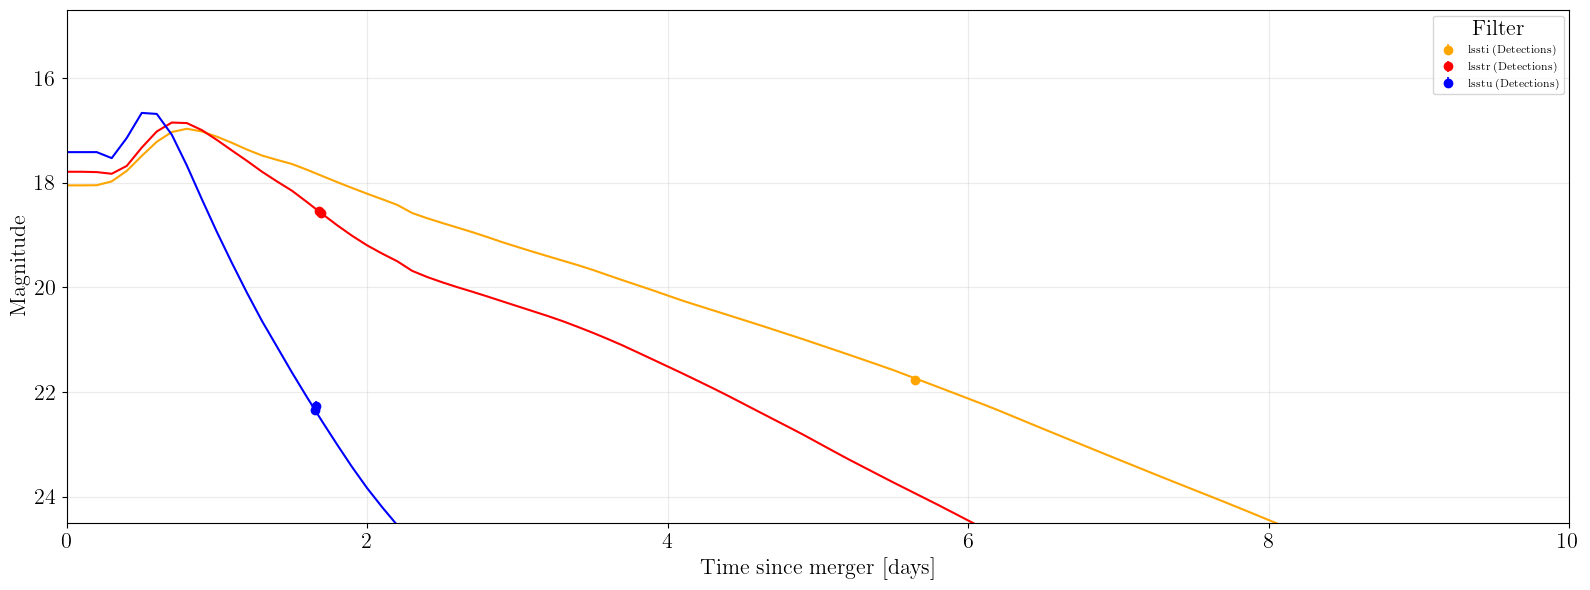

In [7]:
from astropy.time import Time
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from peket.kn_side.utils import generate_synth_lc
%matplotlib inline

color_dic = {
    "u": "blue",
    "g": "green",
    "r": "red",
    "i": "orange",
    "z": "purple",
    "y": "brown",
}
trigger_iso = Time(valid_sources[0]['t0_mjd'], format="mjd", scale="utc").isot

true_ts = valid_sources[0]['t0_mjd'] - np.min(valid_sources[0]['observations']['expMJD']) # t0 - first det 

df_true, _ = generate_synth_lc( # other homemade function to generate synthetic light curves, could have simply used FIESTA/NMMA built in lc generation
    model_name='Bu2026_MLP',
    params=parameters,
    filters=["lssti", "lsstu", "lsstr"],
    noise=0.0,
    max_error=0.0,
    pts_per_day=10,
    delay=0,
    jitter=0,
    trigger_iso=trigger_iso,
    detection_limit_dict=None
)

fig, ax = plt.subplots(figsize=(16, 6))

lc = lc_df.copy()
lc[0] = pd.to_datetime(lc[0])
lc = lc.sort_values(0)
t0 = lc[0].iloc[0]
lc["time_since_merger_days"] = (lc[0] - t0).dt.total_seconds() / 86400.0 - true_ts 
for filt, group in lc.groupby(1):
    # separates UL from detections 
    upper_limits = group[np.isinf(group[3])]
    detections = group[~np.isinf(group[3])]
    ax.errorbar(detections["time_since_merger_days"], detections[2], yerr=detections[3], fmt='o', linewidth=1.2, label=f"{filt} (Detections)", color=color_dic.get(filt[-1], "black"))
    ax.plot(upper_limits["time_since_merger_days"], upper_limits[2], marker='v', ls=' ', color=color_dic.get(filt[-1], "black"))

for filt, group in df_true.groupby(1):
    times = pd.to_datetime(group[0])
    time_since_merger = (times - times.min()).dt.total_seconds() / 86400.0
    ax.plot(time_since_merger, group[2], color=color_dic.get(filt[-1], "black"))
ax.set_ylabel('Magnitude')
ax.legend(title='Filter', loc='best', fontsize=8)
ax.set_xlabel('Time since merger [days]')
ax.set_xlim(0, 10)
ax.grid(True, alpha=0.25)
plt.ylim(24.5, 14.7)
plt.tight_layout()
plt.show()

### example with missing parameters/not supported model:

In [8]:
# use the same param/source BUT with another model
lc_df = generate_synth_lc_lsst(source=valid_sources[0], # output of find_valid_sources or get_source_observations
                               model_name='Ka2017', # All fiesta surrogates are available (if you have already downloaded them) as well as Bu2019lm,Ka2017,LANLTS2 and LANLTP2
                               params = parameters,     # Model parameters 
                               save=False,              # Save the light curve to a (preferably) .dat file
                               filename='synth_lc.dat', # Name of the file to save the light curve (if save=True)
                               svd_path="/home/liteul/memoir_code/NMMA/svdmodels") # Path to the svd models
# error tells which parameters are expected for the model

ValueError: Missing parameter 'log10_mej' for model 'Ka2017'. Expected parameters: ['log10_mej', 'log10_vej', 'log10_Xlan', 'inclination_EM', 'luminosity_distance', 'timeshift']

In [ ]:
# use the same param/source BUT with another model
lc_df = generate_synth_lc_lsst(source=valid_sources[0], # output of find_valid_sources or get_source_observations
                               model_name='Bu2027', # All fiesta surrogates are available (if you have already downloaded them) as well as Bu2019lm,Ka2017,LANLTS2 and LANLTP2
                               params = parameters,     # Model parameters 
                               save=False,              # Save the light curve to a (preferably) .dat file
                               filename='synth_lc.dat', # Name of the file to save the light curve (if save=True)
                               svd_path="/home/liteul/memoir_code/NMMA/svdmodels") # Path to the svd models
# error tells which models are available

ValueError: Model Bu2027 not found in the available models.
List of available models: ['afgpy_gaussian_CVAE', 'afgpy_gaussian_MLP', 'afgpy_tophat_CVAE', 'afgpy_tophat_MLP', 'blastwave_gaussian_CVAE', 'blastwave_rs_gaussian_CVAE', 'pbag_gaussian_CVAE', 'pbag_gaussian_MLP', 'pbag_tophat_CVAE', 'Brethauer2025_CVAE', 'Brethauer2025_MLP', 'Bu2025_CVAE', 'Bu2025_MLP', 'Bu2026_CVAE', 'Bu2026_MLP', 'Bu2019lm', 'Ka2017']